In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Esteban\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# 1. Business Understanding

## Problema
El objetivo es predecir si un cliente aceptará un depósito a término basado en campañas de marketing telefónico.

## Motivación
Optimizar campañas de marketing, reduciendo costos y aumentando la tasa de conversión.

## Tipo de problema
Clasificación binaria supervisada.

# 2. Data Understanding

## Fuente de datos
El dataset proviene del UCI Machine Learning Repository.

## Descripción general
Contiene información de clientes bancarios y resultados de campañas de marketing.

In [6]:
import pandas as pd

df = pd.read_csv("../data/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Observaciones iniciales

- El dataset contiene 45,211 registros y 17 variables.
- Existen variables categóricas y numéricas.
- No se observan valores nulos explícitos.

In [8]:
df['y'].value_counts()
df['y'].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

### Análisis de la variable objetivo

El dataset presenta un desbalance significativo:
- 88% de los clientes no aceptan la oferta
- 12% sí la aceptan

Esto implica que métricas como accuracy pueden ser engañosas.

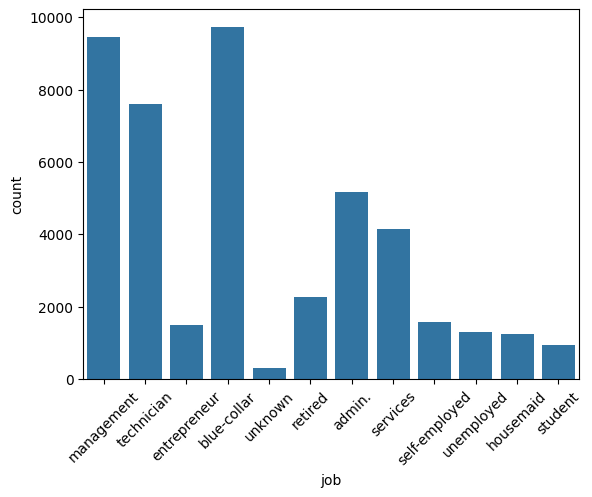

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='job', data=df)
plt.xticks(rotation=45)
plt.show()

### Interpretación

Se observa que la mayoría de clientes pertenece a ciertas categorías laborales.
Algunas categorías podrían tener mayor relación con la aceptación de la oferta.

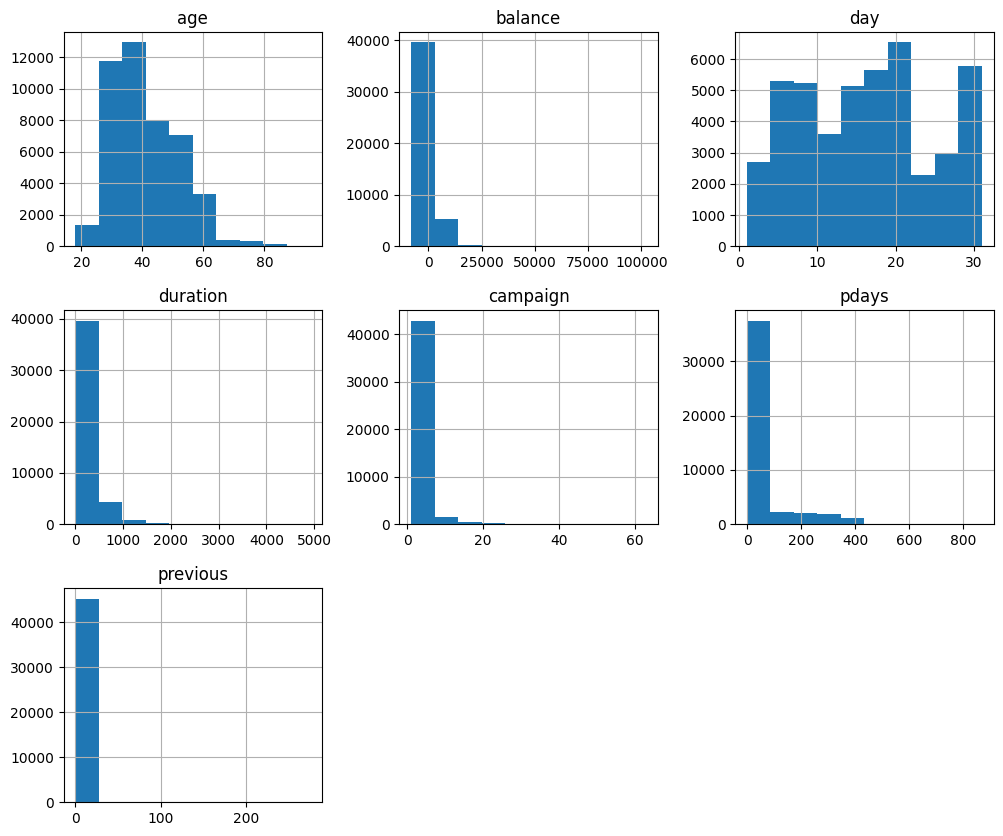

In [10]:
df.hist(figsize=(12,10))
plt.show()

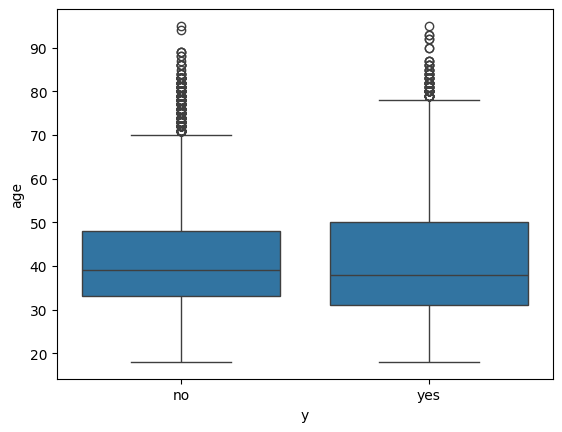

In [11]:
sns.boxplot(x='y', y='age', data=df)
plt.show()

Observación:

La distribución de edad es similar entre clientes que aceptan y no aceptan la oferta, 
aunque los clientes que aceptan tienden a tener una ligera mayor dispersión.

Esto sugiere que la edad por sí sola no es un fuerte predictor.

# Data Quality & Issues

In [18]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

### Problemas identificados

- No hay valores nulos explícitos en el dataset.
- Existen valores "unknown" en variables categóricas, que representan datos faltantes implícitos.
- La variable "duration" presenta data leakage, ya que solo se conoce después de la llamada.

Esto debe tenerse en cuenta en etapas posteriores.

In [19]:
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

## Baseline

Se implementa una regresión logística como modelo base por su simplicidad e interpretabilidad.

In [20]:
X = pd.get_dummies(X, drop_first=True)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\Esteban\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [23]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.34      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043

ROC-AUC: 0.9019307231304443


# Análisis del Baseline

- El modelo alcanza un ROC-AUC cercano a 0.90, lo que indica buena capacidad de discriminación.
- Sin embargo, el recall para la clase positiva es bajo (~34%).

Esto implica que el modelo no identifica correctamente muchos clientes que aceptarían la oferta.

Posibles causas:
- Desbalance del dataset
- Falta de ajuste del modelo

Esto sugiere la necesidad de mejorar el modelo en futuras etapas.

## Métricas

Debido al desbalance del dataset, accuracy no es suficiente.

Se utilizan:
- ROC-AUC: mide capacidad discriminativa
- F1-score: balance entre precisión y recall

# Conclusiones

- El dataset presenta desbalance significativo.
- Se identificaron posibles problemas de calidad como valores "unknown".
- Se detectó data leakage en la variable "duration".
- El baseline muestra buen desempeño en ROC-AUC, pero bajo recall en la clase positiva.
- Existen oportunidades de mejora mediante técnicas de balanceo y ajuste de modelos.